In [79]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.layers import Dense, Activation, Dropout
import keras
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.utils import resample
import random
import seaborn as sns

In [80]:
df_predictors = pd.read_excel('/content/Extended Data_predictors.xlsx')
print(df_predictors.shape)
print(df_predictors.head())

df_target = pd.read_excel('/content/Extended Data_response.xlsx')
print(df_target.shape)
print(df_target.head())

df_full = df_predictors.copy()
df_full['Kc'] = df_target['Kc']

print(df_full.head())

# Проверка на пропуски
print(f"\nПропуски в данных:\n{df_full.isnull().sum()}")

# Разделение 80/20
train_df, test_df = train_test_split(df_full, test_size=0.2, random_state=42)

print(f"Обучающая выборка: {len(train_df)} строк (80%)")
print(f"Тестовая выборка: {len(test_df)} строк (20%)")

# Отделяем предикторы (X) от целевой переменной (y)
X_train = train_df[['a', 'c', 'P']].values
y_train = train_df['Kc'].values

X_test = test_df[['a', 'c', 'P']].values
y_test = test_df['Kc'].values

# Масштабирование
scaler = StandardScaler()
scaler.fit(X_train)
#X_train = scaler.fit_transform(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")

(30000, 4)
           a      c        P       c/a
0  15.630000  49.05  27.3715  3.138196
1  15.860152  49.05  27.3715  3.092656
2  16.090303  49.05  27.3715  3.048420
3  16.320455  49.05  27.3715  3.005431
4  16.550606  49.05  27.3715  2.963638
(30000, 1)
         Kc
0  0.735192
1  0.757003
2  0.779132
3  0.801581
4  0.824348
           a      c        P       c/a        Kc
0  15.630000  49.05  27.3715  3.138196  0.735192
1  15.860152  49.05  27.3715  3.092656  0.757003
2  16.090303  49.05  27.3715  3.048420  0.779132
3  16.320455  49.05  27.3715  3.005431  0.801581
4  16.550606  49.05  27.3715  2.963638  0.824348

Пропуски в данных:
a      0
c      0
P      0
c/a    0
Kc     0
dtype: int64
Обучающая выборка: 24000 строк (80%)
Тестовая выборка: 6000 строк (20%)
Обучающая выборка: (24000, 3)
Тестовая выборка: (6000, 3)


In [81]:
# Набор стратегий для K-Fold кросс-валидации
strategies = [
    {'name': 'A', 'layers': 3, 'neurons': 64, 'activation': 'tanh'},
    {'name': 'B', 'layers': 2, 'neurons': 64, 'activation': 'relu'},
    {'name': 'C', 'layers': 3, 'neurons': 32, 'activation': 'tanh'},
    {'name': 'D', 'layers': 2, 'neurons': 32, 'activation': 'relu'},
    {'name': 'E', 'layers': 3, 'neurons': 64, 'activation': 'relu'}
]

In [82]:
# Функция для создания модели
def build_model(layers, neurons, activation):
    model = Sequential()

    model.add(Dense(neurons, activation=activation, input_shape=(3,)))

    for _ in range(layers - 1):
        model.add(Dense(neurons, activation=activation))
        model.add(Dropout(0.4))

    model.add(Dense(1, activation='elu'))  # регрессия

    model.compile(loss='mean_squared_error', optimizer='adam')

    return model

In [83]:
# K-Fold кросс-валидация
kf = KFold(n_splits=5, shuffle=True, random_state=42)

results = []

for strategy in strategies: # Провекра всех гиперпараметров
    print(f"\nПроверяем стратегию {strategy['name']}...")

    fold_mse = []

    for train_idx, val_idx in kf.split(X_train): # Разделение выборки
        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        model = build_model(
            strategy['layers'],
            strategy['neurons'],
            strategy['activation']
        )

        model.fit(X_tr, y_tr, epochs=50, batch_size=32, verbose=0)

        y_pred = model.predict(X_val, verbose=0)
        mse = mean_squared_error(y_val, y_pred)

        fold_mse.append(mse)

    avg_mse = np.mean(fold_mse)

# Добавление модели и ее результатов в словарь
    results.append({
        'name': strategy['name'],
        'layers': strategy['layers'],
        'neurons': strategy['neurons'],
        'activation': strategy['activation'],
        'mean_mse': avg_mse
    })

    print(f"MSE: {avg_mse:.4f}")


Проверяем стратегию A...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr

MSE: 0.0041

Проверяем стратегию B...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr

MSE: 0.0011

Проверяем стратегию C...


...

MSE: 0.0046

Проверяем стратегию D...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr

MSE: 0.0017

Проверяем стратегию E...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr

MSE: 0.0044


In [84]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='mean_mse') # Сортировка по среднему MSE

print("\nВсе стратегии:")
print(results_df)

print("\nЛУЧШАЯ СТРАТЕГИЯ:")
print(results_df.iloc[0])


Все стратегии:
  name  layers  neurons activation  mean_mse
1    B       2       64       relu  0.001135
3    D       2       32       relu  0.001689
0    A       3       64       tanh  0.004082
4    E       3       64       relu  0.004435
2    C       3       32       tanh  0.004645

ЛУЧШАЯ СТРАТЕГИЯ:
name                 B
layers               2
neurons             64
activation        relu
mean_mse      0.001135
Name: 1, dtype: object


In [85]:
value = [27.3715,23.01,7.96274] # Значения пористости
n_models = 10
models = []
mse_list = []
X_testm = []
y_testm = []

# Разбиение выборки по разной пористости
for i in value:
    df_test = test_df[test_df['P'] == i].copy()

    X_test1 = df_test[['a', 'c', 'P']].values
    X_test1 = scaler.transform(X_test1)

    X_testm.append(X_test1)
    y_testm.append(df_test['Kc'].values)

# Обучение 10 нейронных сетей
for i in range(n_models):
    print(f"Модель {i+1}")

    X_boot, y_boot = resample(X_train, y_train, replace=True) # Создание бутстрап-выборки

    model = build_model(int(results_df.iloc[0, 1]), int(results_df.iloc[0, 2]), results_df.iloc[0, 3]) # Создание модели с лучшими гиперпараметрами

    model.fit(X_boot, y_boot, epochs=50, batch_size=32, verbose=0)

    mse_con = []

    for i in range(3): # Предсказание для разной пористости
        y_pred = model.predict(X_testm[i], verbose=0)

        mse_con.append(mean_squared_error(y_testm[i], y_pred))
        print(f"mse({value[i]}): {mse_con[i]:.6f}")

    mse = np.mean(mse_con)
    models.append(model)
    mse_list.append(mse)

    print(f"MSE: {mse:.6f}")

Модель 1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


mse(27.3715): 0.001324
mse(23.01): 0.001864
mse(7.96274): 0.001387
MSE: 0.001525
Модель 2


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


mse(27.3715): 0.000625
mse(23.01): 0.000811
mse(7.96274): 0.001799
MSE: 0.001078
Модель 3


...

mse(27.3715): 0.001526
mse(23.01): 0.001432
mse(7.96274): 0.002050
MSE: 0.001669
Модель 9


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


mse(27.3715): 0.000768
mse(23.01): 0.000842
mse(7.96274): 0.001157
MSE: 0.000922
Модель 10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


mse(27.3715): 0.001353
mse(23.01): 0.001259
mse(7.96274): 0.001913
MSE: 0.001508


In [86]:
# Выявление 5 лучших моделей
best_indices = np.argsort(mse_list)[:5]
best_models = [models[i] for i in best_indices]

mse = []
mse_data = []

# Предсказание на 5 лучших моделях и объединение их в ансамбль
for i in range(3):
    pred_con = []

    for model in best_models:
        pred = model.predict(X_testm[i], verbose=0)
        mse_data.append(mean_squared_error(y_testm[i], pred))
        pred_con.append(pred)

    predictions = np.mean(pred_con, axis=0)
    mse.append(mean_squared_error(y_testm[i], predictions))
    print(f"MSE({value[i]}): {mse[i]:.6f}")

ensemble_mse = np.mean(mse)
print(f"Ансамбль MSE: {ensemble_mse:.6f}")

MSE(27.3715): 0.000667
MSE(23.01): 0.000718
MSE(7.96274): 0.001100
Ансамбль MSE: 0.000828


In [87]:
data = []

# Построение датафрейма с результатами моделей
for i in range(5):
    j = (mse_data[i] + mse_data[i+5] + mse_data[i+10])/3
    data.append({"Модель": best_indices[i]+1,
            "0.0%": mse_data[i],
            "0.1%": mse_data[i+5],
            "0.5%": mse_data[i+10],
            "MSE": j})

result_df = pd.DataFrame(data)
print(result_df)

   Модель      0.0%      0.1%      0.5%       MSE
0       9  0.000768  0.000842  0.001157  0.000922
1       4  0.000920  0.000849  0.001264  0.001011
2       2  0.000625  0.000811  0.001799  0.001078
3       7  0.001095  0.001174  0.001163  0.001144
4      10  0.001353  0.001259  0.001913  0.001508


In [88]:
# Формирование новой выборки для прогнозирования поверхностей K_IC (P,a,c) для концентраций МУНТ от 0.0 до 0.5 масс.%
MWCNT_con = np.arange(0, 0.51, 0.01)
P_con = np.linspace(27.3715, 7.96274, len(MWCNT_con))
a = np.linspace(15.63, 38.415, 100)
c = np.linspace(49.05, 108.24, 100)

data = []
for i in P_con:
    for j in c:
        for n in a:
            data.append({"a": n,
                    "c": j,
                    "P": i})

new_X = pd.DataFrame(data)

new_X1 = scaler.transform(new_X)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [89]:
ensemble_pred = []
pred_mean = []

# Предсказание модлей на новой выборке
for model in best_models:
    pred = model.predict(new_X1, verbose=0)
    predictions = []
    for i in P_con:
        df_test = new_X.copy()
        df_test['Kc'] = pred
        df_test = df_test[df_test['P'] == i].copy()
        q = df_test['Kc'].values

        predictions.append(np.mean(q))

    pred_mean.append(predictions)

ensemble_pred = np.mean(pred_mean, axis=0)

hg = []

# Расчет исходных экспериментальных данных
for i in value:
    df_test = df_full.copy()
    df_test = df_test[df_test['P'] == i].copy()
    hg.append(np.mean(df_test['Kc'].values))

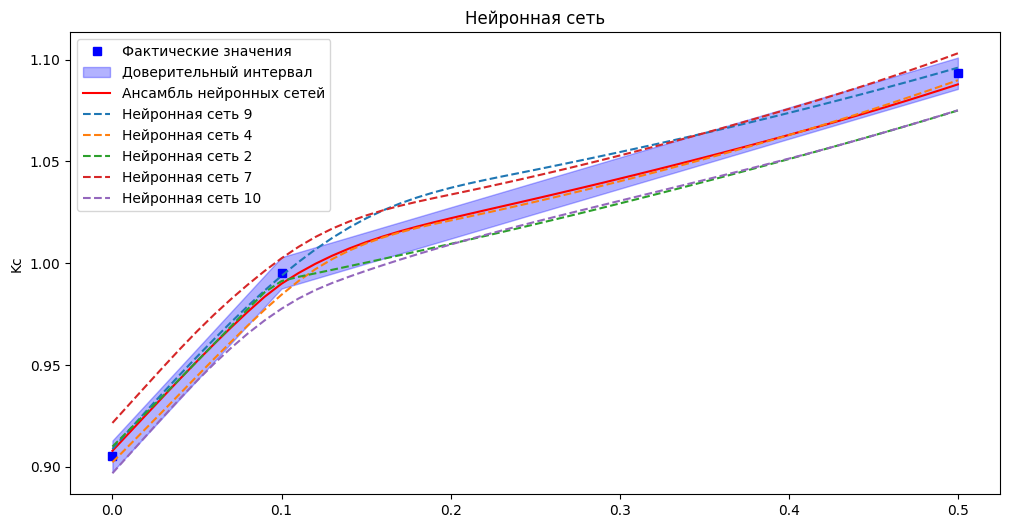

In [90]:
# Построение графиков
plt.figure(figsize=(12, 6))
x_points = MWCNT_con
y_points = ensemble_pred
x_points1 = [0, 0.1, 0.5]
y_points1 = hg
ci = 0.1 * np.std(y_points1) / np.mean(y_points1)
plt.plot(x_points1, y_points1, marker ='s', linestyle ='', color='blue', label='Фактические значения')
plt.fill_between(x_points1, (y_points1-ci), (y_points1+ci), color='blue', alpha=0.3, label='Доверительный интервал')
plt.plot(x_points, y_points, color='red', label='Ансамбль нейронных сетей')
for i in range(5):
    plt.plot(x_points, pred_mean[i], linestyle ='--', label=f'Нейронная сеть {best_indices[i]+1}')
plt.ylabel('Kc')
plt.title('Нейронная сеть')
plt.legend()
plt.show()